In [30]:
import math
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [43]:
class Value:

    def __init__(self, data, _prev = (), _op = '', label = ''):

        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_prev)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value({self.label} = {self.data})"
    
    def __add__(self, other):
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        other = other if isinstance(other, Value) else Value(other)
        _sum = self.data + other.data
        out = Value(_sum, (self, other), '+')
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        other = other if isinstance(other, Value) else Value(other)
        prod = self.data * other.data
        out = Value(prod, (self, other), '*')
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def tanh(self):
        def _backward():
            self.grad += (1 - out.data ** 2) * out.grad

        out = Value((math.exp(2 * self.data) - 1) / (math.exp(2 * self.data) + 1), (self, ), 'tanh')
        out._backward = _backward
        return out

    def exp(self):
        def _backward():
            self.grad += out.data * out.grad

        out = Value(math.exp(self.data), (self, ), 'e')
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self, ), '**')
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * (other ** -1)
    
    def __rsub__(self, other):
        return (-self) + other
    
    def __rtruediv__(self, other):
        return (self ** -1) * other
    
    def __sub__(self, other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def backward(self):
        self.grad = 1

        topo = []
        visited = set()

        def build(v):
            if v not in visited:
                visited.add(v)
                for i in v._prev:
                    build(i)
                topo.append(v)
        build(self)

        for i in reversed(topo):
            i._backward()

In [32]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [33]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(L = -8.0)

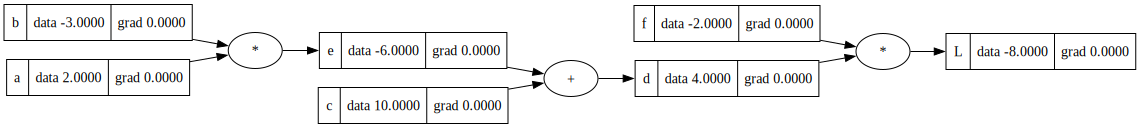

In [34]:
draw_dot(L)

In [35]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
e = (2 * n).exp()
o = (e - 1) / (e + 1) ; o.label = 'o'

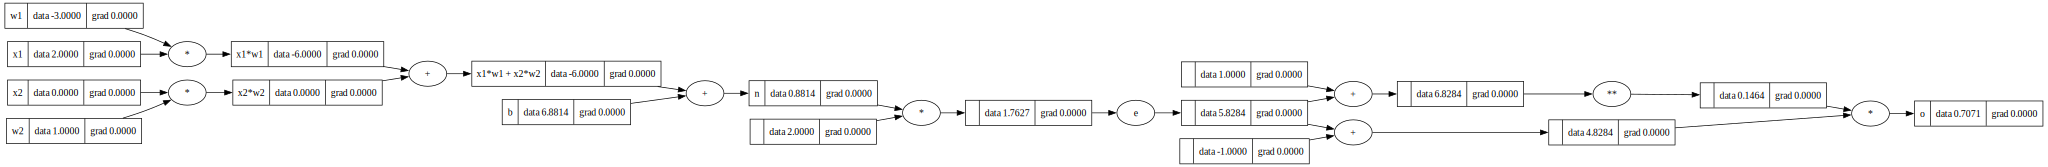

In [36]:
draw_dot(o)

In [37]:
o.backward()

In [38]:
import random

In [102]:
class Neuron:

    def __init__(self, inputs):
        self.w = [Value(random.uniform(-1, 1)) for i in range(inputs)]
        self.b = Value(random.uniform(-1, 1))
    
    def __call__(self, x):
        s = sum((W * I for W,I in zip(self.w, x)), self.b)
        out = s.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    

class Layer:

    def __init__(self, inputs, outputs):
        self.neurons = [Neuron(inputs) for i in range(outputs)]
        
    def __call__(self, x):
        out = [i(x) for i in self.neurons]
        return out[0] if len(out) == 1 else out
    
    def parameters(self):
        return [p for neurons in self.neurons for p in neurons.parameters()]
    
class MLP:

    def __init__(self, inputs, outputs):
        sizes = [inputs] + outputs
        self.layers = [Layer(sizes[i], sizes[i + 1]) for i in range(len(outputs))]

    def __call__(self, x):
        for i in self.layers:
            x = i(x)
        return x
    
    def parameters(self):
        return [p for layers in self.layers for p in layers.parameters()]

In [103]:
x = [2.3, 3.4, -1.7]
n = MLP(3, [4, 4, 1])
n(x)

Value( = -0.723141669270372)

In [139]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
n = MLP(3, [4, 4, 1])

In [128]:
ypred = [n(i) for i in xs]
ypred
loss = sum((yact - ypre) ** 2 for yact, ypre in zip(ys, ypred))
print(loss)
loss.backward()

Value( = 3.482130009834008)


In [126]:
n.parameters()
len(n.parameters())

41

In [127]:
for p in n.parameters():
    p.data -= 0.01 * p.grad

In [300]:
for i in range(100):

    # forward pass
    ypred = [n(i) for i in xs]
    loss = sum((yact - ypre) ** 2 for yact, ypre in zip(ys, ypred))
    print(loss)

    # backward pass
    for p in n.parameters():
        p.grad = 0
    loss.backward()

    # update params
    for p in n.parameters():
        p.data -= 0.05 * p.grad

print(ypred)

Value( = 9.152281259994607e-06)
Value( = 9.152214047646933e-06)
Value( = 9.152146836286334e-06)
Value( = 9.152079625912834e-06)
Value( = 9.152012416524761e-06)
Value( = 9.151945208123743e-06)
Value( = 9.151878000708178e-06)
Value( = 9.151810794279639e-06)
Value( = 9.151743588836493e-06)
Value( = 9.151676384380767e-06)
Value( = 9.151609180911696e-06)
Value( = 9.151541978426998e-06)
Value( = 9.151474776929637e-06)
Value( = 9.151407576418292e-06)
Value( = 9.151340376893335e-06)
Value( = 9.15127317835431e-06)
Value( = 9.151205980801656e-06)
Value( = 9.151138784234604e-06)
Value( = 9.151071588653853e-06)
Value( = 9.151004394059092e-06)
Value( = 9.150937200449651e-06)
Value( = 9.150870007827442e-06)
Value( = 9.150802816191203e-06)
Value( = 9.15073562554017e-06)
Value( = 9.150668435875776e-06)
Value( = 9.150601247196916e-06)
Value( = 9.15053405950369e-06)
Value( = 9.150466872796349e-06)
Value( = 9.15039968707552e-06)
Value( = 9.150332502339615e-06)
Value( = 9.150265318590559e-06)
Value( = 9.1